Original image shape: (1920, 1080, 3)
Original image dtype: float32
Image size: 1080 x 1920
Channels: 3
Grayscale shape: (1920, 1080)


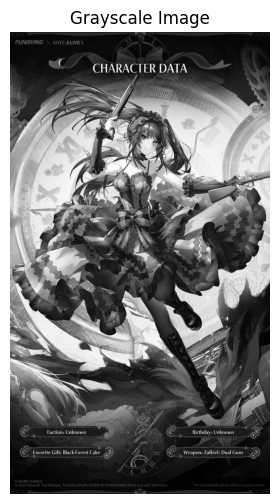


7x7 Gaussian Kernel:
[[1.9651916e-05 2.3940935e-04 1.0729582e-03 1.7690092e-03 1.0729582e-03
  2.3940935e-04 1.9651916e-05]
 [2.3940935e-04 2.9166031e-03 1.3071309e-02 2.1550942e-02 1.3071309e-02
  2.9166031e-03 2.3940935e-04]
 [1.0729582e-03 1.3071309e-02 5.8581535e-02 9.6584626e-02 5.8581535e-02
  1.3071309e-02 1.0729582e-03]
 [1.7690092e-03 2.1550942e-02 9.6584626e-02 1.5924112e-01 9.6584626e-02
  2.1550942e-02 1.7690092e-03]
 [1.0729582e-03 1.3071309e-02 5.8581535e-02 9.6584626e-02 5.8581535e-02
  1.3071309e-02 1.0729582e-03]
 [2.3940935e-04 2.9166031e-03 1.3071309e-02 2.1550942e-02 1.3071309e-02
  2.9166031e-03 2.3940935e-04]
 [1.9651916e-05 2.3940935e-04 1.0729582e-03 1.7690092e-03 1.0729582e-03
  2.3940935e-04 1.9651916e-05]]

Kernel sum: 1.0

CPU GAUSSIAN BLUR

CPU Gaussian blur time: 48.15196180343628 seconds

LABWORK 5 - GAUSSIAN BLUR EXPERIMENT

Block size:  4 x  4 | Threads/block:   16 | Grid:  270 x  480
    Global  | Time: 0.010148 s | Speedup: 4745.10x
    Shared  | Tim

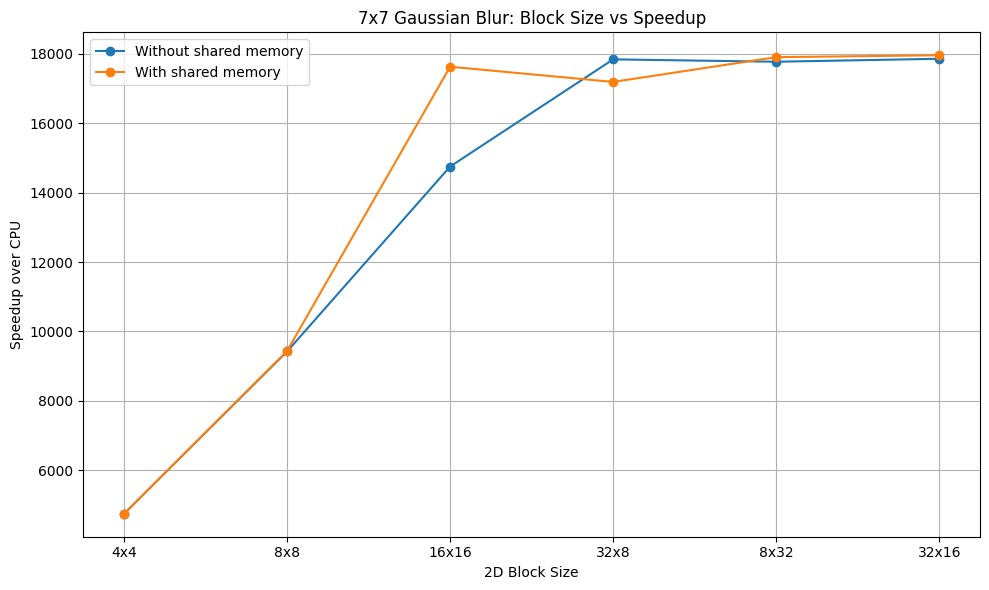

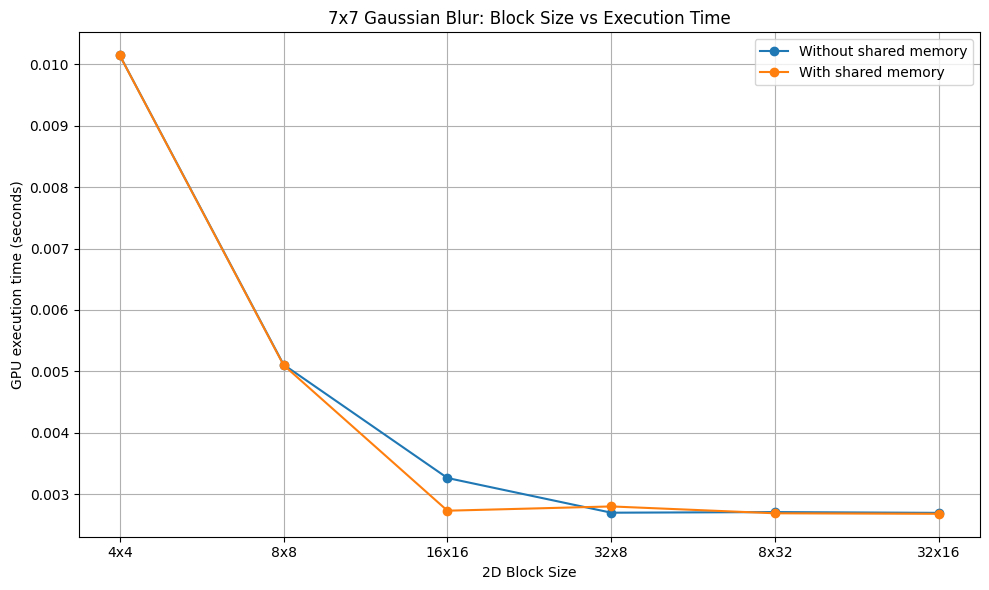

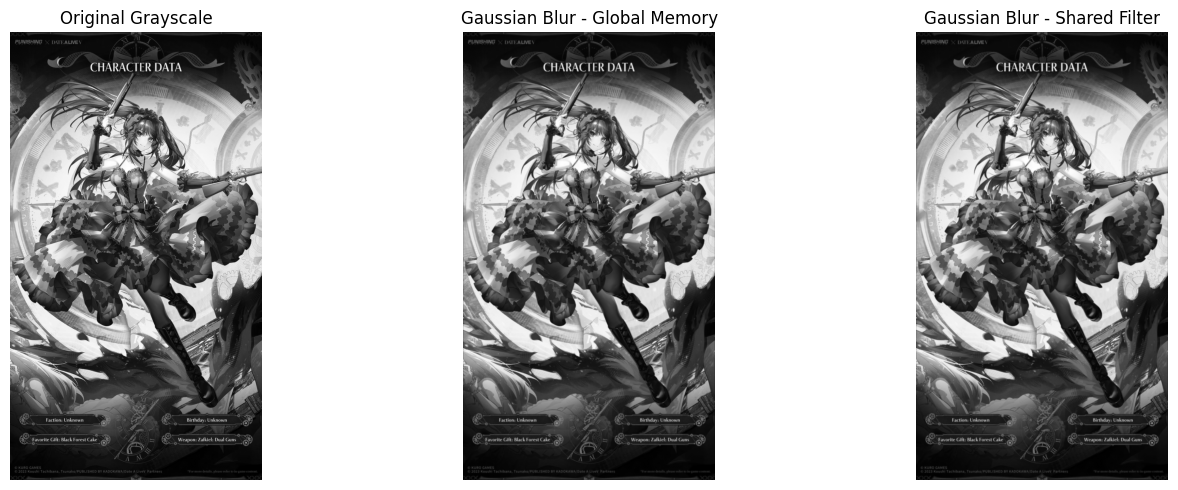


LABWORK 5 SUMMARY

Image size              : 1080 x 1920
Total pixels            : 2073600
Gaussian filter         : 7 x 7
Sigma                   : 1.0
CPU time                : 48.151962 s
Best global block       : 32 x 16
Best global GPU time    : 0.002696 s
Best global speedup     : 17860.27x
Best shared block       : 32 x 16
Best shared GPU time    : 0.002681 s
Best shared speedup     : 17961.29x
Shared / Global speed   : 1.01x
Global validation       : PASS
Shared validation       : PASS


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from numba import cuda
import time

# 1. Load image and convert to grayscale

img = mpimg.imread("/content/img.jpg")

if img.ndim == 3 and img.shape[2] == 4:
    img = img[:, :, :3]

img = img.astype(np.float32)

height, width, channels = img.shape

print("Original image shape:", img.shape)
print("Original image dtype:", img.dtype)
print("Image size:", width, "x", height)
print("Channels:", channels)

gray = (
    0.299 * img[:, :, 0]
    + 0.587 * img[:, :, 1]
    + 0.114 * img[:, :, 2]
).astype(np.float32)

print("Grayscale shape:", gray.shape)

plt.figure(figsize=(8, 6))
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

# 2. Create 7x7 Gaussian filter

KERNEL_SIZE = 7
RADIUS = 3
sigma = 1.0

axis = np.arange(-RADIUS, RADIUS + 1, dtype=np.float32)
xx, yy = np.meshgrid(axis, axis)

gaussian_kernel = np.exp(
    -(xx * xx + yy * yy) / (2 * sigma * sigma)
)
gaussian_kernel /= gaussian_kernel.sum()
gaussian_kernel = gaussian_kernel.astype(np.float32)

print("\n7x7 Gaussian Kernel:")
print(gaussian_kernel)
print("\nKernel sum:", gaussian_kernel.sum())

# 3. CPU Gaussian blur

def gaussian_blur_cpu(image, kernel):
    h, w = image.shape
    r = kernel.shape[0] // 2

    padded = np.pad(
        image,
        ((r, r), (r, r)),
        mode="constant"
    )

    output = np.zeros_like(image)

    for y in range(h):
        for x in range(w):
            value = 0.0

            for ky in range(KERNEL_SIZE):
                for kx in range(KERNEL_SIZE):
                    value += (
                        padded[y + ky, x + kx]
                        * kernel[ky, kx]
                    )

            output[y, x] = value

    return output


print("\nCPU GAUSSIAN BLUR\n")

start = time.time()
blur_cpu = gaussian_blur_cpu(gray, gaussian_kernel)
cpu_time = time.time() - start

print("CPU Gaussian blur time:", cpu_time, "seconds")

plt.imsave(
    "/content/gaussian_blur_cpu.jpg",
    blur_cpu,
    cmap="gray"
)

# 4. CUDA Gaussian blur - global memory

@cuda.jit
def gaussian_blur_global(image, output, kernel):

    x, y = cuda.grid(2)

    h, w = image.shape

    if x < w and y < h:
        value = 0.0

        for ky in range(7):
            for kx in range(7):

                ix = x + kx - 3
                iy = y + ky - 3

                if 0 <= ix < w and 0 <= iy < h:
                    value += (
                        image[iy, ix]
                        * kernel[ky, kx]
                    )

        output[y, x] = value

# 5. CUDA Gaussian blur - shared memory

@cuda.jit
def gaussian_blur_shared(image, output, kernel):

    shared_kernel = cuda.shared.array(
        (7, 7),
        dtype=np.float32
    )

    tx = cuda.threadIdx.x
    ty = cuda.threadIdx.y

    threads = cuda.blockDim.x * cuda.blockDim.y
    tid = ty * cuda.blockDim.x + tx

    # Copy all 49 filter values cooperatively.
    for i in range(tid, 49, threads):
        ky = i // 7
        kx = i % 7
        shared_kernel[ky, kx] = kernel[ky, kx]

    cuda.syncthreads()

    x, y = cuda.grid(2)

    h, w = image.shape

    if x < w and y < h:
        value = 0.0

        for ky in range(7):
            for kx in range(7):

                ix = x + kx - 3
                iy = y + ky - 3

                if 0 <= ix < w and 0 <= iy < h:
                    value += (
                        image[iy, ix]
                        * shared_kernel[ky, kx]
                    )

        output[y, x] = value

# 6. Copy data to GPU

d_gray = cuda.to_device(gray)
d_kernel = cuda.to_device(gaussian_kernel)

d_global = cuda.device_array(
    gray.shape,
    dtype=np.float32
)

d_shared = cuda.device_array(
    gray.shape,
    dtype=np.float32
)

# 7. Timing functions

def measure(kernel, block_x, block_y, repetitions=5):

    grid_x = (width + block_x - 1) // block_x
    grid_y = (height + block_y - 1) // block_y

    times = []

    for _ in range(repetitions):

        start = time.time()

        kernel[(grid_x, grid_y), (block_x, block_y)](
            d_gray,
            d_global if kernel == gaussian_blur_global else d_shared,
            d_kernel
        )

        cuda.synchronize()
        times.append(time.time() - start)

    return np.mean(times), grid_x, grid_y

# 8. Warm-up

warmup = (16, 16)

wx = (width + warmup[0] - 1) // warmup[0]
wy = (height + warmup[1] - 1) // warmup[1]

gaussian_blur_global[(wx, wy), warmup](
    d_gray, d_global, d_kernel
)

gaussian_blur_shared[(wx, wy), warmup](
    d_gray, d_shared, d_kernel
)

cuda.synchronize()

# 9. Test different block sizes

block_sizes = [
    (4, 4),
    (8, 8),
    (16, 16),
    (32, 8),
    (8, 32),
    (32, 16)
]

global_times = []
shared_times = []

global_speedups = []
shared_speedups = []

print("\nLABWORK 5 - GAUSSIAN BLUR EXPERIMENT\n")

for bx, by in block_sizes:

    gt, gx, gy = measure(
        gaussian_blur_global,
        bx, by
    )

    st, _, _ = measure(
        gaussian_blur_shared,
        bx, by
    )

    global_times.append(gt)
    shared_times.append(st)

    global_speedups.append(cpu_time / gt)
    shared_speedups.append(cpu_time / st)

    print(
        f"Block size: {bx:2d} x {by:2d} "
        f"| Threads/block: {bx * by:4d} "
        f"| Grid: {gx:4d} x {gy:4d}"
    )

    print(
        f"    Global  | Time: {gt:.6f} s "
        f"| Speedup: {cpu_time / gt:.2f}x"
    )

    print(
        f"    Shared  | Time: {st:.6f} s "
        f"| Speedup: {cpu_time / st:.2f}x\n"
    )

# 10. Find best configurations

gi = np.argmin(global_times)
si = np.argmin(shared_times)

best_global_block = block_sizes[gi]
best_shared_block = block_sizes[si]

best_global_time = global_times[gi]
best_shared_time = shared_times[si]

best_global_speedup = global_speedups[gi]
best_shared_speedup = shared_speedups[si]

print("\nBEST CONFIGURATIONS\n")

print(
    "Best global-memory block:",
    best_global_block[0], "x", best_global_block[1]
)

print(
    "Best global-memory time:",
    best_global_time, "seconds"
)

print(
    "Best global-memory speedup:",
    best_global_speedup, "x"
)

print()

print(
    "Best shared-memory block:",
    best_shared_block[0], "x", best_shared_block[1]
)

print(
    "Best shared-memory time:",
    best_shared_time, "seconds"
)

print(
    "Best shared-memory speedup:",
    best_shared_speedup, "x"
)

# 11. Run best configurations for validation

def run_best(kernel, block, output):

    bx, by = block

    gx = (width + bx - 1) // bx
    gy = (height + by - 1) // by

    kernel[(gx, gy), (bx, by)](
        d_gray,
        output,
        d_kernel
    )

    cuda.synchronize()
    return output.copy_to_host()


blur_global = run_best(
    gaussian_blur_global,
    best_global_block,
    d_global
)

blur_shared = run_best(
    gaussian_blur_shared,
    best_shared_block,
    d_shared
)

# 12. Validation

diff_global = np.abs(blur_cpu - blur_global)
diff_shared = np.abs(blur_cpu - blur_shared)

global_valid = np.allclose(
    blur_cpu,
    blur_global,
    atol=1e-5
)

shared_valid = np.allclose(
    blur_cpu,
    blur_shared,
    atol=1e-5
)

print("\nVALIDATION\n")

print(
    "Global maximum difference:",
    np.max(diff_global)
)

print(
    "Global mean difference:",
    np.mean(diff_global)
)

print(
    "Shared maximum difference:",
    np.max(diff_shared)
)

print(
    "Shared mean difference:",
    np.mean(diff_shared)
)

print(
    "Global-memory validation:",
    "PASS" if global_valid else "FAIL"
)

print(
    "Shared-memory validation:",
    "PASS" if shared_valid else "FAIL"
)

# 13. Final performance comparison

shared_vs_global = (
    best_global_time / best_shared_time
)

print("\nFINAL PERFORMANCE COMPARISON\n")

print(f"CPU time              : {cpu_time:.6f} s")
print(f"Best global GPU time  : {best_global_time:.6f} s")
print(f"Global GPU speedup    : {best_global_speedup:.2f}x")
print(f"Best shared GPU time  : {best_shared_time:.6f} s")
print(f"Shared GPU speedup    : {best_shared_speedup:.2f}x")
print(f"Shared vs global GPU  : {shared_vs_global:.2f}x")

# 14. Speedup graph

labels = [
    f"{x}x{y}"
    for x, y in block_sizes
]

plt.figure(figsize=(10, 6))

plt.plot(
    labels,
    global_speedups,
    marker="o",
    label="Without shared memory"
)

plt.plot(
    labels,
    shared_speedups,
    marker="o",
    label="With shared memory"
)

plt.xlabel("2D Block Size")
plt.ylabel("Speedup over CPU")
plt.title("7x7 Gaussian Blur: Block Size vs Speedup")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig(
    "/content/gaussian_block_size_vs_speedup.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 15. Execution-time graph

plt.figure(figsize=(10, 6))

plt.plot(
    labels,
    global_times,
    marker="o",
    label="Without shared memory"
)

plt.plot(
    labels,
    shared_times,
    marker="o",
    label="With shared memory"
)

plt.xlabel("2D Block Size")
plt.ylabel("GPU execution time (seconds)")
plt.title("7x7 Gaussian Blur: Block Size vs Execution Time")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig(
    "/content/gaussian_block_size_vs_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 16. Visual comparison
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(gray, cmap="gray")
plt.title("Original Grayscale")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(blur_global, cmap="gray")
plt.title("Gaussian Blur - Global Memory")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(blur_shared, cmap="gray")
plt.title("Gaussian Blur - Shared Filter")
plt.axis("off")

plt.tight_layout()
plt.show()

# 17. Summary

print("\nLABWORK 5 SUMMARY\n")

print(f"Image size              : {width} x {height}")
print(f"Total pixels            : {width * height}")
print(f"Gaussian filter         : 7 x 7")
print(f"Sigma                   : {sigma}")
print(f"CPU time                : {cpu_time:.6f} s")

print(
    f"Best global block       : "
    f"{best_global_block[0]} x {best_global_block[1]}"
)

print(f"Best global GPU time    : {best_global_time:.6f} s")
print(f"Best global speedup     : {best_global_speedup:.2f}x")

print(
    f"Best shared block       : "
    f"{best_shared_block[0]} x {best_shared_block[1]}"
)

print(f"Best shared GPU time    : {best_shared_time:.6f} s")
print(f"Best shared speedup     : {best_shared_speedup:.2f}x")
print(f"Shared / Global speed   : {shared_vs_global:.2f}x")

print(
    "Global validation       :",
    "PASS" if global_valid else "FAIL"
)

print(
    "Shared validation       :",
    "PASS" if shared_valid else "FAIL"
)